
# Step-by-step Guide: Constructing a model with Phydrus

*Authors: R.A. Collenteur & M. Vremec*

This notebook is part of a manuscript that is currently being prepared (spring 2020): 

*R.A. Collenteur, G. Brunetti, M. Vremec & J. Simunek (in preparation) Phydrus: a Python implementation of the Hydrus-1D model.*

---

This Notebook presents the basics steps to create a Phydrus model simulating water flow through the vadose zone. In the presented example, the workflow is divided into several steps, to demonstrate the usage of Phydrus methods:
1. Import the Phydrus package
2. Create the basic model
3. Add processes and materials
4. Add soil profile
5. Add Root Water Uptake
6. Add atmospheric boundary condition
7. Add observations nodes
8. Simulate the model
9. Post-process the results
___

### 1. Import the Pydrus package

In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import phydrus as ps

### 2. Create the basic model & add time information
In the code block below a `Model` instance is created. The path to the Hydrus-1D executable has to be set at this stage. Phydrus will check the executable, and raise an Error if it is not found. 

In [2]:
ws = "sim_out"

phydrus_dir = os.path.dirname(ps.__file__)
exe = os.path.abspath(os.path.join(phydrus_dir, "..", "hydrus1d", "bin", "hydrus"))

# Create model
ml = ps.Model(exe_name=exe, ws_name=ws, name="model",
              time_unit="days", length_unit="cm")

ml.add_time_info(tinit=0, tmax=730, print_times=True, l_short=False);

### 3. Add processes and materials
In this step a model for the water flow is selected and top and bottom boundary conditions, using the `ml.add_waterflow` method. After that, we can use the `get_empty_material_df` method to obtain an empty DataFrame to define our soil hydraulic parameters for the different soil materials. In this example, the model contains to soil materials.

In [3]:
ml.add_waterflow(model=0, top_bc=3, bot_bc=4)

m = ml.get_empty_material_df(n=2)
m.loc[0:2] = [[0.0, 0.3382, 0.0111, 1.4737, 13, 0.5],
              [0.0, 0.3579, 0.0145, 1.5234, 50, 0.5]]
ml.add_material(m)

### 4. Add Profile information
We develop the linear function of potential root water uptake distribution  $S^*_{p}(z)$ vs depth, following Hoffman and van Genuchten. 


\begin{equation}
S^*_{p} = \left \{
\begin{aligned}
&1 && \text{for} && z>L-r_1 \\
&\frac{z-[L-(r_1 + r_2)]}{r_2} && \text{for} && L-r_1 \geq z \geq L-(r_1 + r_2) \\
&0 && \text{for} && L-r_1 z < L-(r_1 + r_2) 
\end{aligned} \right.
\end{equation} 

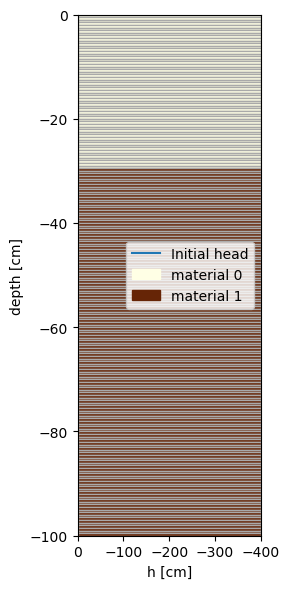

In [4]:
# Define loop for potential root water uptake distribution proposed by Hoffman and Van Genuchten
def z_loop(z, r1 = 10, r2 = 20):
    if z > -r1:
        return 1
    elif z < -(r1 + r2):
        return 0
    else:
        return(z+(r1+r2))/r2

bottom = [-30, -100]  # Depth of the soil column
nodes = 150  # Dictretize into n nodes
ihead = -500  # Determine initial pressure head

profile = ps.create_profile(bot=bottom, dx=0.5, h=ihead, mat=[1,2])
profile["Beta"] = profile.apply(lambda row: z_loop(row["x"]), axis=1)
ml.add_profile(profile)
ml.plots.profile(figsize=(3,6))


# ### 5. Add atmosphere boundary conditions
# # Read atmospheric data and add to the model
atm = pd.read_csv("../data/atmosphere.csv", index_col=0)
atm.index = pd.to_timedelta(atm.index, unit="days")
ml.add_atmospheric_bc(atm, hcrits=0)

### 6. Add root water uptake

In [5]:
ml.add_root_uptake(model=0, crootmax=100, omegac=0, p2h=-1500, p2l=-1500, poptm=[-25, -25])

### 7. Add observation nodes

In [6]:
#Number of the node -- > write script to get node closest to desired depth
ml.add_obs_nodes([-30, -60])

### 8. Write hydrus input files & run hydrus 
Before we can simulate, we write all model information to files. 

In [7]:
ml.write_input()
ml.simulate()

INFO: Successfully wrote sim_out/SELECTOR.IN
INFO: Successfully wrote sim_out/PROFILE.DAT
INFO: Successfully wrote sim_out/ATMOSPH.IN
INFO: Hydrus-1D Simulation Successful.


CompletedProcess(args=['/Users/veethahavya/Desktop/phydrus/hydrus1d/bin/hydrus', 'sim_out', '-1'], returncode=0)

### 9a. Plot results
Plot pressure for soil column at the end of the simulation.

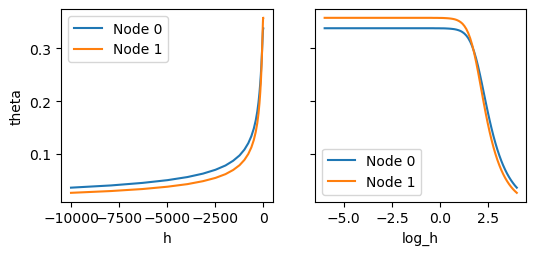

In [8]:
ml.plots.soil_properties(figsize=(6, 2.5))
plt.savefig(os.path.join(ws, "soil_properties.png"), bbox_inches="tight", dpi=300)

### 9b. Plot the drainage over time

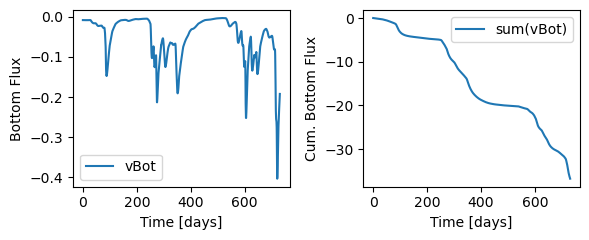

In [9]:
axes = ml.plots.water_flow("Bottom Flux", figsize=(6, 2.5))
plt.savefig(os.path.join(ws, "water_flow.png"), bbox_inches="tight", dpi=300)

### 9c. Plot the water content over time

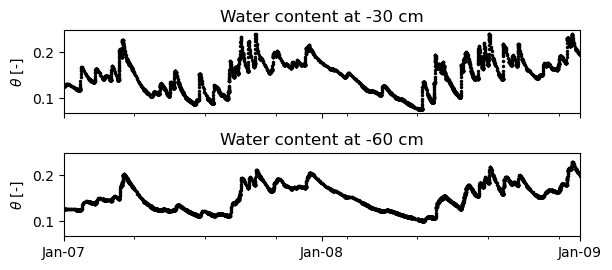

In [10]:
df = ml.read_obs_node()

fig, [ax0, ax1] = plt.subplots(2,1, figsize=(6,3), sharex=True, sharey=True)
df[ml.obs_nodes[0]]["theta"].plot(ax=ax0, marker=".", c="k", linestyle="", markersize=3)
ax0.set_title("Water content at -30 cm")
ax0.set_ylabel(r"$\theta$ [-]")

df[ml.obs_nodes[1]]["theta"].plot(ax=ax1, marker=".", c="k", linestyle="", markersize=3)
ax1.set_title("Water content at -60 cm")
ax1.set_ylabel(r"$\theta$ [-]")
plt.tight_layout()
ax1.set_xlabel("")
ax1.set_xlim(0,730)
ax1.set_xticks([0,365,730])
ax1.set_xticklabels(["Jan-07", "Jan-08", "Jan-09"])
plt.savefig(os.path.join(ws, "water_content.png"), bbox_inches="tight", dpi=300)

In [12]:
df[ml.obs_nodes[0]].to_csv(os.path.join(ws, "wc_30cm.csv"))
df[ml.obs_nodes[1]].to_csv(os.path.join(ws, "wc_60cm.csv"))

### 9c. Update the soil profile plot with the pressure head

<Axes: xlabel='h [cm]', ylabel='depth [cm]'>

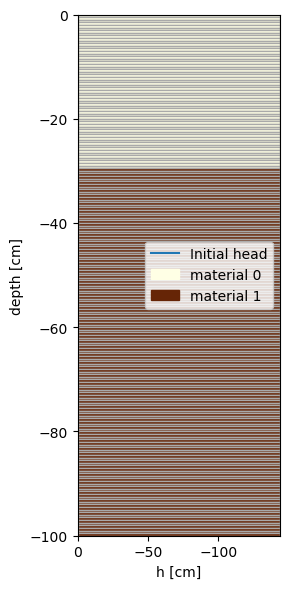

In [13]:
all_nod = ml.read_nod_inf()
# Use last time step with valid (non-NaN) head values
valid_times = [t for t, df in sorted(all_nod.items()) if not df["Head"].isna().all()]
last_valid = valid_times[-1] if valid_times else 730
nod_df = all_nod[last_valid].dropna(subset=["Head"])
# Align to profile length (NOD_INF may have one extra row for outlet)
head = nod_df["Head"].iloc[:len(ml.profile)]
ml.profile.loc[:, "h"] = head.values
ml.plots.profile()